In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized import TVqRegularized
from bimpcc.models.tvq_denoising import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()

In [4]:
scale = 64

In [5]:
dataset = get_dataset("cameraman",scale=scale)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

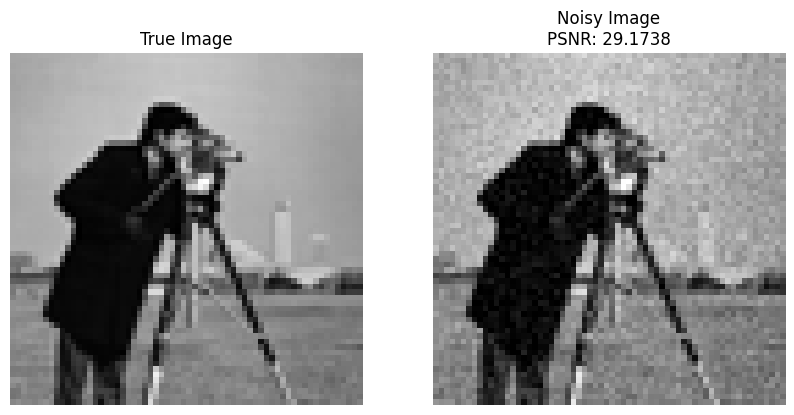

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [7]:
model = TVqRegularized(true, noisy, epsilon=1e-3, q_param=0.99)

In [8]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

alpha= [0.001]

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:   119210
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

alpha= [0.001]
alpha= [0.00999999]
Total number of variables............................:    12161
                     variables with only lower bounds:     4097
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints......

/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:123: RuntimeWarning: invalid value encountered in power
  - beta * q_param / normKu * (normKu + (q_param - 1) / gamma) ** (q_param - 1),
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:198: RuntimeWarning: invalid value encountered in power
  (1 / (normKu**3)) * (normKu + (q_param - 1) / gamma) ** (q_param - 1)
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:200: RuntimeWarning: invalid value encountered in power
  * (normKu + (q_param - 1) / gamma) ** (q_param - 2)
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:203: RuntimeWarning: invalid value encountered in power
  e = (beta * delta_gamma) / normKu - (beta * q_param / normKu) * (
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:211: RuntimeWarning: invalid value encountered in power
  delta_gamma - q_param * (normKu + (q_param - 1) / gamma) ** (q_param - 1)

alpha= [0.01994263]
   3  1.4656745e+00 3.98e-02 6.46e+01  -2.1 5.87e-02    -  9.31e-01 1.00e+00f  1
alpha= [0.03029649]
   4  1.8121845e+00 6.05e-02 7.89e+00  -1.9 4.34e-02    -  7.44e-01 1.00e+00h  1
alpha= [0.02973875]
   5  1.7528351e+00 5.75e-02 1.45e+00  -2.0 4.25e-02    -  1.00e+00 1.00e+00h  1
alpha= [0.03052669]
   6  1.7912843e+00 6.06e-02 5.24e+00  -2.0 3.35e-02    -  1.00e+00 1.00e+00h  1
alpha= [0.03091639]
   7  1.8127488e+00 6.14e-02 4.51e+00  -2.0 2.59e-02    -  1.00e+00 1.00e+00h  1
alpha= [0.03110937]
   8  1.8231172e+00 6.18e-02 1.77e+00  -2.0 1.49e-02    -  1.00e+00 1.00e+00h  1
alpha= [0.03116425]
   9  1.8262048e+00 3.78e-02 7.48e-01  -2.0 9.53e-03    -  1.00e+00 1.00e+00h  1
alpha= [0.02648272]
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10  1.5914953e+00 5.28e-02 4.29e+00  -2.9 3.13e-02    -  1.00e+00 1.00e+00h  1
alpha= [0.00477506]
  11  1.2980717e+00 1.59e-01 1.32e+00  -3.0 2.94e-01    -  1.00e+00 5.55e-01h  1
alpha= [0.

In [9]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

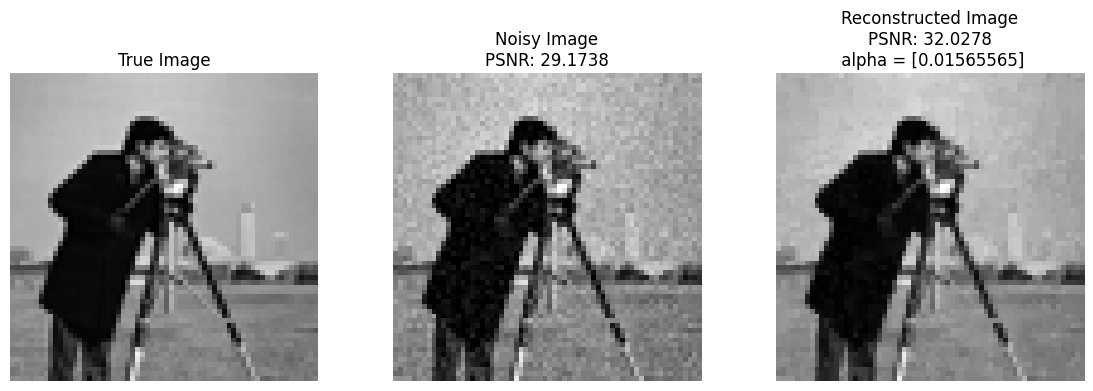

In [10]:
u_scaled = u.reshape((scale,scale))
plot_experiment(true,noisy,u_scaled,alpha)